# Dynamic Metric Weights: Weight Divergence vs. Loss

Visualize how the EWM (exponential weighted moving average) weights for **WD (Weight Divergence)** and **Loss** evolve over communication rounds.

Data source: `fedgra_keras_exact_mnist_-train-20260615_023523-c2a79bf0_selection_log.csv`

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add root for style
root_dir = Path("../../..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))
from style import MatplotlibStyle
MatplotlibStyle().apply()

print("✅ Imports ready.")


✅ Imports ready.


In [2]:
# ============================================================
# Load the selection log
# ============================================================

CSV_FILE = "fedgra_keras_exact_mnist_-train-20260615_023523-c2a79bf0_selection_log.csv"

df = pd.read_csv(CSV_FILE)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Rounds: {df['round'].min()} – {df['round'].max()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nWD weight  range: [{df['weight_divergence'].min():.4f}, {df['weight_divergence'].max():.4f}]")
print(f"Loss weight range: [{df['loss'].min():.4f}, {df['loss'].max():.4f}]")
print(f"WD + Loss ≈ 1?  max deviation = {(df['weight_divergence'] + df['loss'] - 1).abs().max():.6f}")


Shape: (101, 4)
Columns: ['round', 'selected_clients', 'weight_divergence', 'loss']
Rounds: 0 – 100

First 5 rows:
   round                   selected_clients  weight_divergence      loss
0      0  client.3@group-1;client.5@group-1           0.235658  0.764342
1      1  client.4@group-1;client.6@group-1           0.423133  0.576867
2      2  client.6@group-1;client.7@group-1           0.391937  0.608063
3      3  client.4@group-1;client.8@group-1           0.467151  0.532849
4      4  client.2@group-1;client.5@group-1           0.426441  0.573559

WD weight  range: [0.2357, 0.5910]
Loss weight range: [0.4090, 0.7643]
WD + Loss ≈ 1?  max deviation = 0.000000


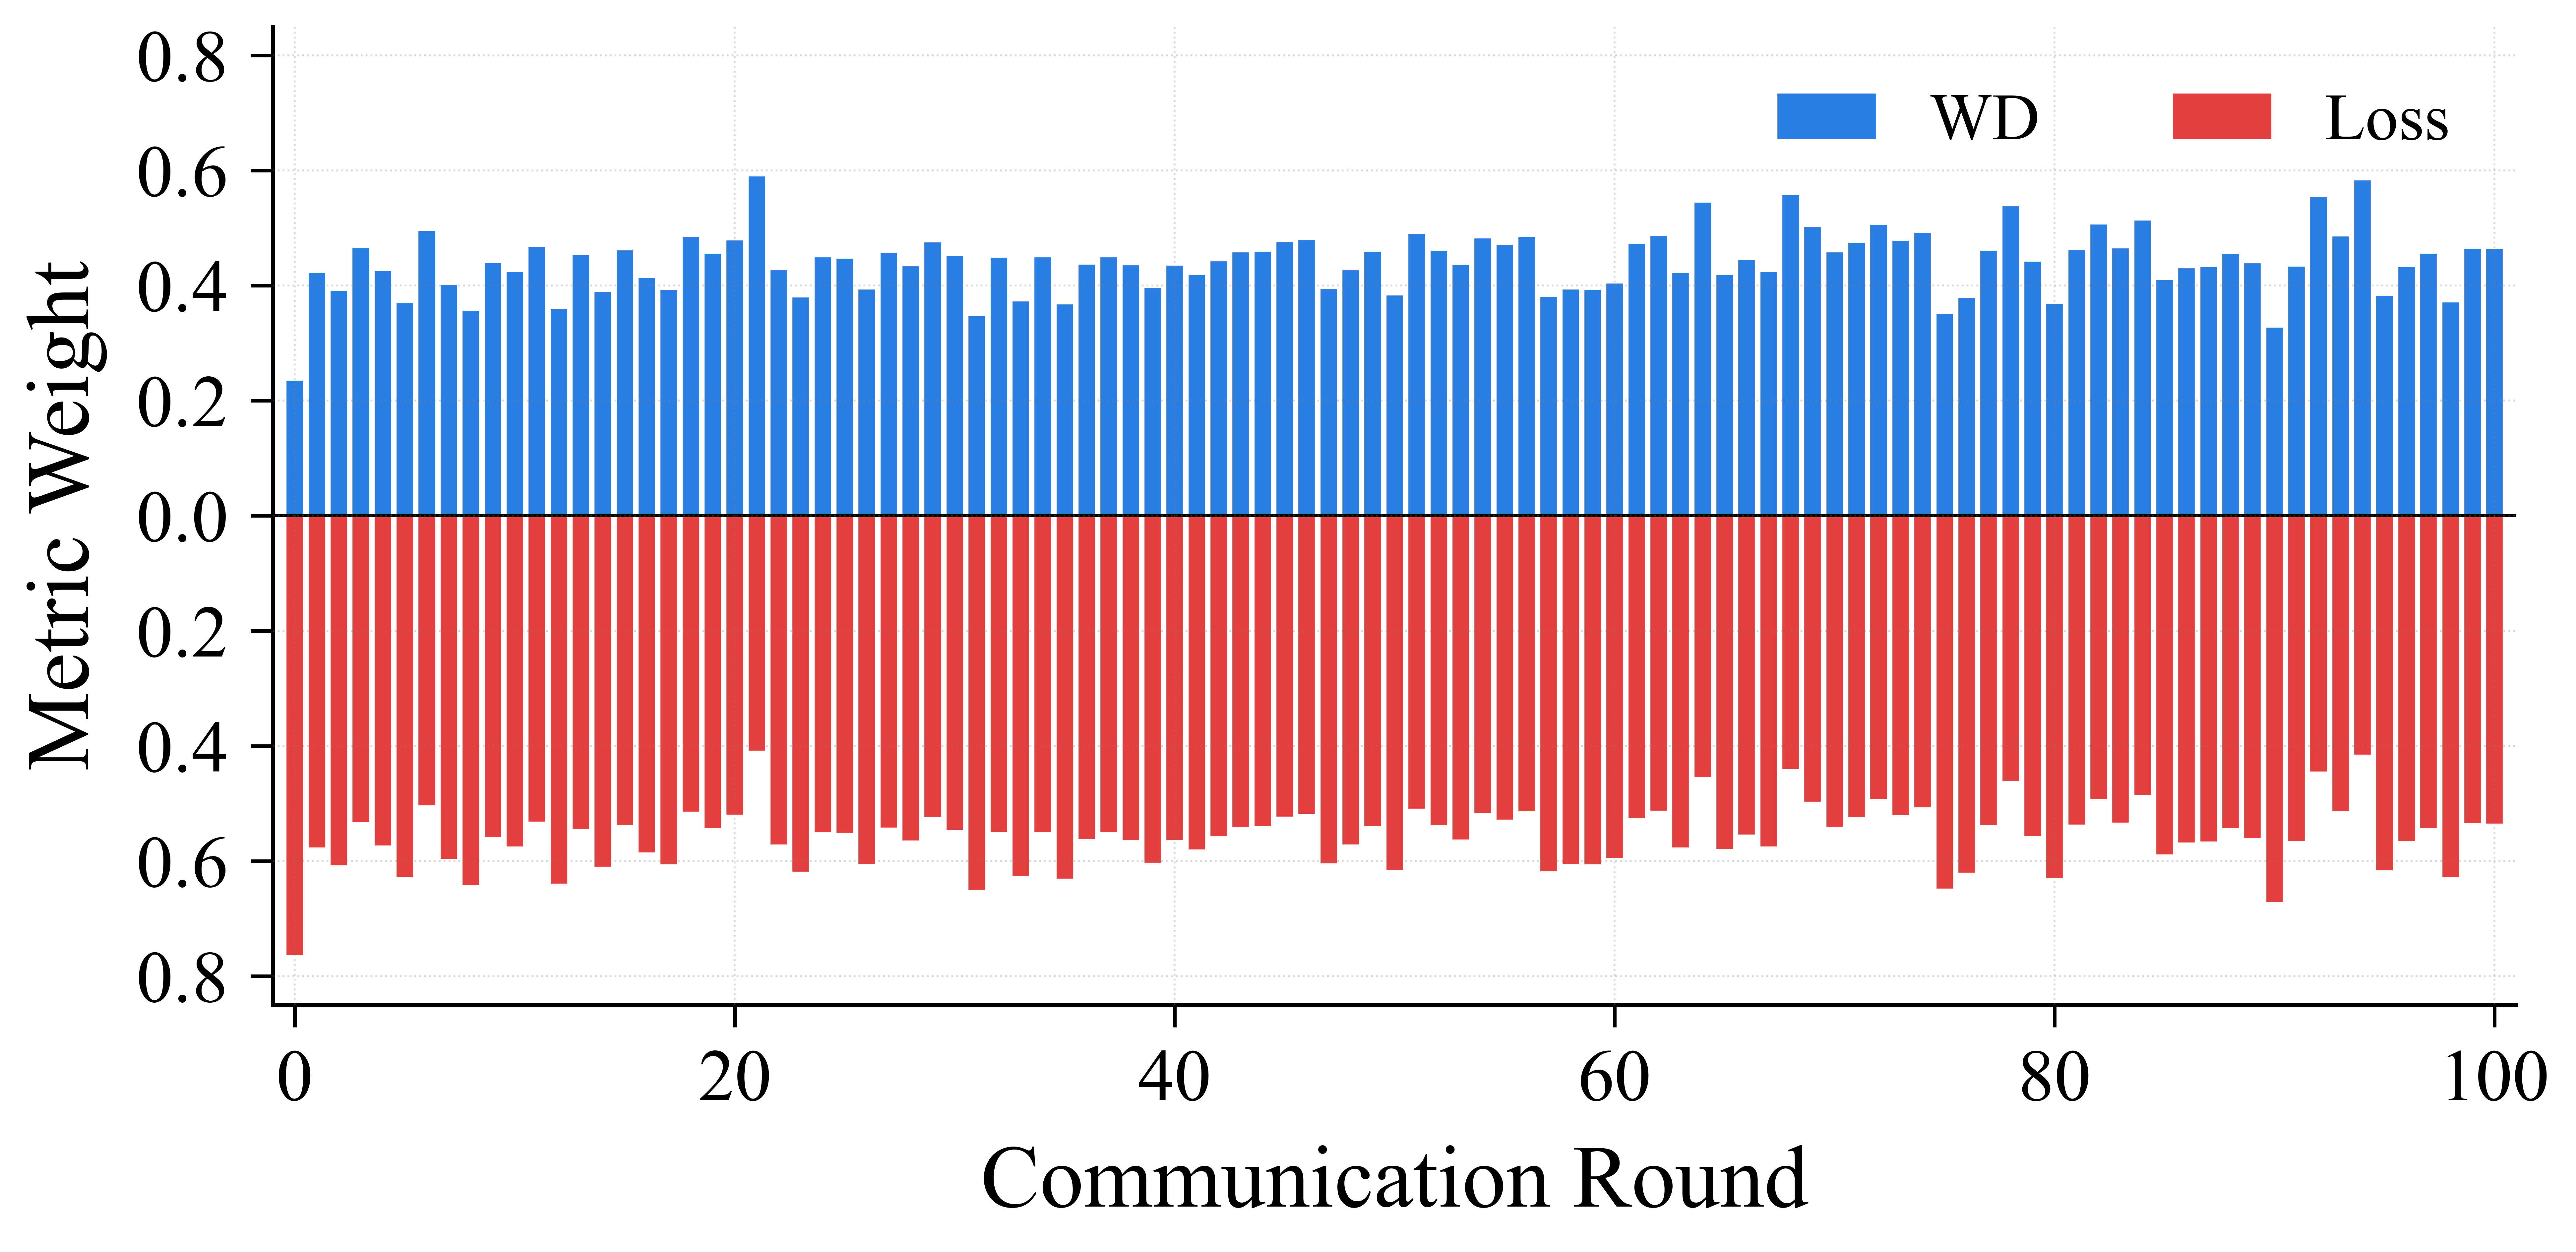

In [9]:
# ============================================================
# Diverging Bar Chart: WD (up, blue) vs Loss (down, red)
# ============================================================

rounds = df["round"].values
wd_weights = df["weight_divergence"].values
loss_weights = df["loss"].values

fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.8

# Blue bars above x-axis: Weight Divergence
ax.bar(rounds, wd_weights, width=bar_width,
       color="#2a7de1", edgecolor="white", linewidth=0.3,
       label="WD")

# Red bars below x-axis: Loss (plotted as negative)
ax.bar(rounds, -loss_weights, width=bar_width,
       color="#e53e3e", edgecolor="white", linewidth=0.3,
       label="Loss")

# --- Axis & labels ---
ax.set_xlabel("Communication Round", fontsize=24)
ax.set_ylabel("Metric Weight", fontsize=24)
ax.set_xlim(-1, len(rounds))
ax.set_ylim(-0.85, 0.85)

# Y-axis ticks: show absolute values
ax.set_yticks([-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.8", "0.6", "0.4", "0.2", "0.0", "0.2", "0.4", "0.6", "0.8"])

# Horizontal reference line at y=0
ax.axhline(y=0, color="black", linewidth=0.8)

# Legend
ax.legend(fontsize=18, loc="upper right", frameon=False, ncol=2)


plt.tight_layout()
plt.savefig("weight_trend.pdf", dpi=800)
plt.show()
